<a href="https://colab.research.google.com/github/sawantarya232-blip/Deep-Learning/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving download.jpg to download.jpg
Image features extracted successfully!
Vocabulary Size: 21
Maximum Caption Length: 9
Training samples: 43
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1395 - loss: 3.1426
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1860 - loss: 2.7947
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.2093 - loss: 2.6819
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.3256 - loss: 2.4842
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.2791 - loss: 2.3482
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3953 - loss: 2.0761
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4186 - loss: 1.9613
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4419 - loss: 1.8583
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4884 - loss: 1.7659
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4419 - loss: 1.6599
Epoch 11/30
6/6 ━━━━━━━━━━━

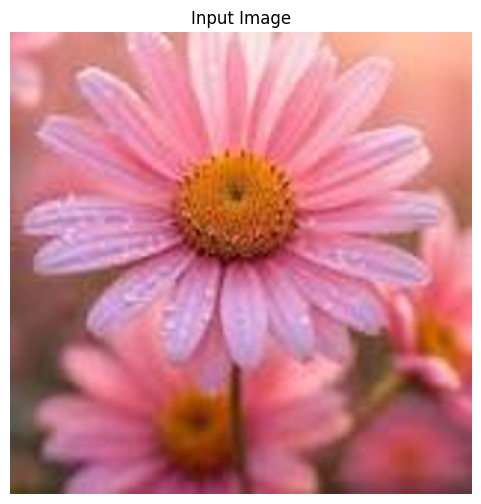

Generated Caption: a a is sitting outside


In [ ]:
# Install required libraries
!pip install tensorflow pillow numpy matplotlib -q

# Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Add

# Load CNN model for image feature extraction
cnn = InceptionV3(weights="imagenet", include_top=True)
cnn_model = Model(cnn.input, cnn.layers[-2].output)

# Upload input image
from google.colab import files

uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Load and resize image
image = Image.open(image_path).convert("RGB").resize((299, 299))

# Preprocess image
img = np.array(image)
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)

# Extract image features using CNN
image_features = cnn_model.predict(img, verbose=0)

print("Image features extracted successfully!")

# Sample training captions
captions = [
    "startseq a dog is playing in the park endseq",
    "startseq a cat is sitting on the chair endseq",
    "startseq a man is riding a bicycle endseq",
    "startseq a girl is playing with a dog endseq",
    "startseq a dog is running outside endseq",
    "startseq a cat is sitting outside endseq"
]

# Tokenize captions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

print("Vocabulary Size:", vocab_size)
print("Maximum Caption Length:", max_length)

# Create input-output sequences
X_text = []
y_text = []

for caption in captions:
    sequence = tokenizer.texts_to_sequences([caption])[0]

    for i in range(1, len(sequence)):
        X_text.append(sequence[:i])
        y_text.append(sequence[i])

# Pad text sequences
X_text = pad_sequences(
    X_text,
    maxlen=max_length,
    padding="post"
)

y_text = np.array(y_text)

# Define CNN input
image_input = Input(shape=(2048,))

# Define text input
text_input = Input(shape=(max_length,))

# Process CNN features
image_dense = Dense(256, activation="relu")(image_input)

# Word embedding
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=256
)(text_input)

# Process text using LSTM
lstm = LSTM(256)(embedding)

# Combine CNN and LSTM features
combined = Add()([image_dense, lstm])

# Predict next word
output = Dense(
    vocab_size,
    activation="softmax"
)(combined)

# Create CNN-LSTM model
model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Repeat image features for each training sequence
X_image = np.repeat(
    image_features,
    len(X_text),
    axis=0
)

print("Training samples:", len(X_text))

# Train CNN-LSTM model
history = model.fit(
    [X_image, X_text],
    y_text,
    epochs=30,
    batch_size=8,
    verbose=1
)

# Function to generate caption
def generate_caption(image_feature):

    caption = "startseq"

    for _ in range(max_length):

        # Convert caption to sequence
        sequence = tokenizer.texts_to_sequences([caption])[0]

        # Pad sequence
        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding="post"
        )

        # Predict next word
        prediction = model.predict(
            [image_feature, sequence],
            verbose=0
        )

        # Select word with highest probability
        word_id = np.argmax(prediction[0])

        # Convert number to word
        word = tokenizer.index_word.get(word_id)

        # Stop if no word or end token is predicted
        if word is None or word == "endseq":
            break

        # Add predicted word
        caption += " " + word

    return caption.replace("startseq", "").strip()

# Generate caption
caption = generate_caption(image_features)

# Display uploaded image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Display generated caption
print("Generated Caption:", caption)